In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [3]:
import zipfile
import os

zip_path = '/content/archive (1).zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('Dataset Extracted Successfully')

Dataset Extracted Successfully


In [4]:
import os

base_dir = '/content/dataset/Oily-Dry-Skin-Types'

for folder in ['train', 'valid', 'test']:
    print(f'\n{folder.upper()}')
    path = os.path.join(base_dir, folder)

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        print(cls, '->', len(os.listdir(cls_path)), 'images')


TRAIN
oily -> 1000 images
normal -> 1104 images
dry -> 652 images

VALID
oily -> 80 images
normal -> 111 images
dry -> 71 images

TEST
oily -> 40 images
normal -> 59 images
dry -> 35 images


In [5]:
!pip install -q tensorflow gradio

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np
import os

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = '/content/dataset/Oily-Dry-Skin-Types/train'
valid_dir = '/content/dataset/Oily-Dry-Skin-Types/valid'
test_dir = '/content/dataset/Oily-Dry-Skin-Types/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
      class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2756 images belonging to 3 classes.
Found 262 images belonging to 3 classes.
Found 134 images belonging to 3 classes.


In [8]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
      Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 87s 380ms/step - accuracy: 0.3734 - loss: 1.3001 - val_accuracy: 0.3893 - val_loss: 1.1304 - learning_rate: 1.0000e-04
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - accuracy: 0.4017 - loss: 1.1366 - val_accuracy: 0.4046 - val_loss: 1.0829 - learning_rate: 1.0000e-04
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 38s 218ms/step - accuracy: 0.4416 - loss: 1.0626 - val_accuracy: 0.4084 - val_loss: 1.0761 - learning_rate: 1.0000e-04
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 37s 216ms/step - accuracy: 0.4761 - loss: 1.0200 - val_accuracy: 0.4160 - val_loss: 1.0710 - learning_rate: 1.0000e-04
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 37s 215ms/step - accuracy: 0.4750 - loss: 1.0345 - val_accuracy: 0.3893 - val_loss: 1.0748 - learning_rate: 1.0000e-04
Epoch 6/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.4915 - loss: 1.0059
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
173/173 ━━━━━━━━━━━━━━━━━━━━ 37s 214ms/s

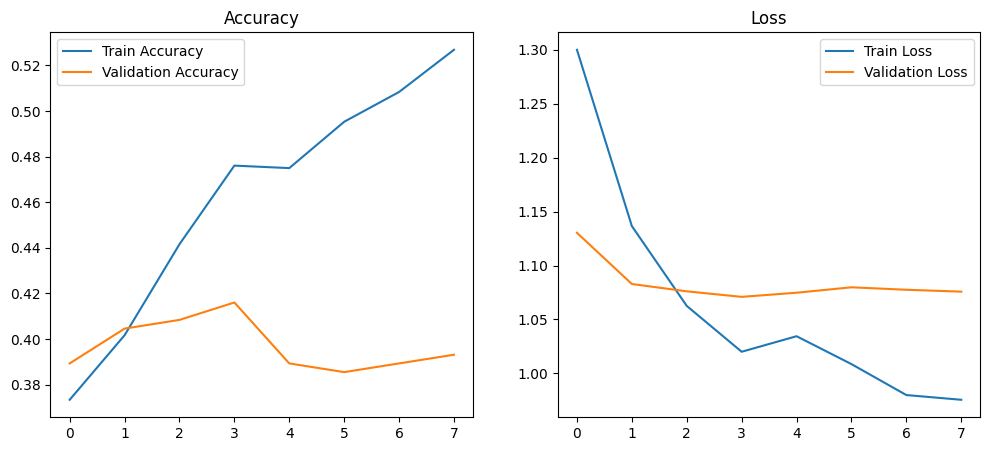

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [12]:
loss, accuracy = model.evaluate(test_generator)

print('Test Accuracy:', accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4030 - loss: 1.0673
Test Accuracy: 0.4029850661754608


In [13]:
from sklearn.metrics import classification_report

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 577ms/step
              precision    recall  f1-score   support

         dry       0.30      0.17      0.22        35
      normal       0.56      0.41      0.47        59
        oily       0.34      0.60      0.43        40

    accuracy                           0.40       134
   macro avg       0.40      0.39      0.37       134
weighted avg       0.43      0.40      0.39       134



In [14]:
model.save('/content/skin_type_classifier.h5')

print('Model Saved Successfully')

Model Saved Successfully


In [15]:
from tensorflow.keras.preprocessing import image

img_path = '/content/oily_ba1d4c45e8dd3d76c15d_jpg.rf.5203bf0762119ee6ed560abecffc1727.jpg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

classes = ['dry', 'normal', 'oily']


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


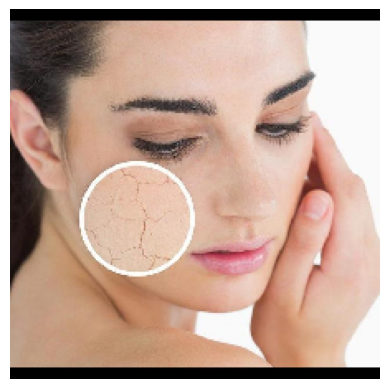

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Skin Type : dry
Confidence : 55.9 %


In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

# LOAD SAVED MODEL
model = tf.keras.models.load_model('/content/skin_type_classifier.h5')

# IMAGE PATH
img_path = '/content/dry_7d1580f09a0f22cbb869_jpg.rf.e23e6348aba524a6564650d07f1210b5.jpg'

# LOAD IMAGE
img = image.load_img(img_path, target_size=(224,224))

# DISPLAY IMAGE
plt.imshow(img)
plt.axis('off')
plt.show()

# CONVERT IMAGE TO ARRAY
img_array = image.img_to_array(img)

# NORMALIZE IMAGE
img_array = img_array / 255.0

# EXPAND DIMENSIONS
img_array = np.expand_dims(img_array, axis=0)

# PREDICTION
prediction = model.predict(img_array)

# CLASSES
classes = ['dry', 'normal', 'oily']

# GET PREDICTED CLASS
predicted_class = classes[np.argmax(prediction)]

# GET CONFIDENCE
confidence = np.max(prediction) * 100

# PRINT RESULT
print("Predicted Skin Type :", predicted_class)
print("Confidence :", round(confidence,2), "%")

In [17]:
import gradio as gr
import tensorflow as tf
import numpy as np

from tensorflow.keras.preprocessing import image

# LOAD MODEL
model = tf.keras.models.load_model('/content/skin_type_classifier.h5')

# CLASS NAMES
classes = ['dry', 'normal', 'oily']

# PREDICTION FUNCTION
def predict_skin(img):

    # Resize image
    img = img.resize((224,224))

    # Convert to array
    img_array = image.img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)

    # Get class
    predicted_class = classes[np.argmax(prediction)]

    # Confidence
    confidence = float(np.max(prediction) * 100)

    # Return result
    return f"Skin Type: {predicted_class}\nConfidence: {confidence:.2f}%"

# CREATE INTERFACE
interface = gr.Interface(
    fn=predict_skin,
    inputs=gr.Image(type='pil'),
    outputs='text',
    title='Skin Type Classification System',
    description='Upload a skin image to classify skin type.'
)

# LAUNCH
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3a9e04dcfe2c021ff1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
from google.colab import files
files.download('/content/skin_type_classifier.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>